In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  


In [2]:
# Open model and config files
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[1].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[0].id)

# Merge into a data tree
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_global = NEMODataTree.from_datasets(datasets = datasets)

# Clip to North Atlantic 
bbox = (-85.0, 0.0, 0.0, 80.0)
dt_clipped = dt_global.clip_grid(grid="gridT", bbox=bbox)

# Add lat and lon as co-ordinates
dt = dt_clipped.add_geoindex(grid="gridT")

# Convert to dataset
ds = (dt['gridT']).dataset




            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [ ]:
## Consider 40 W, 55N 

point = ds.sel(gphit = 55.0, glamt = -40.0, method = 'nearest')
temp90 = point['thetao_con'].where(ds['time_counter'].dt.year == 1990, drop =True).compute()
temp00 = point['thetao_con'].where(ds['time_counter'].dt.year == 2000, drop =True).compute()
temp10 = point['thetao_con'].where(ds['time_counter'].dt.year == 2010, drop =True).compute()
temp20 = point['thetao_con'].where(ds['time_counter'].dt.year == 2020, drop =True).compute()

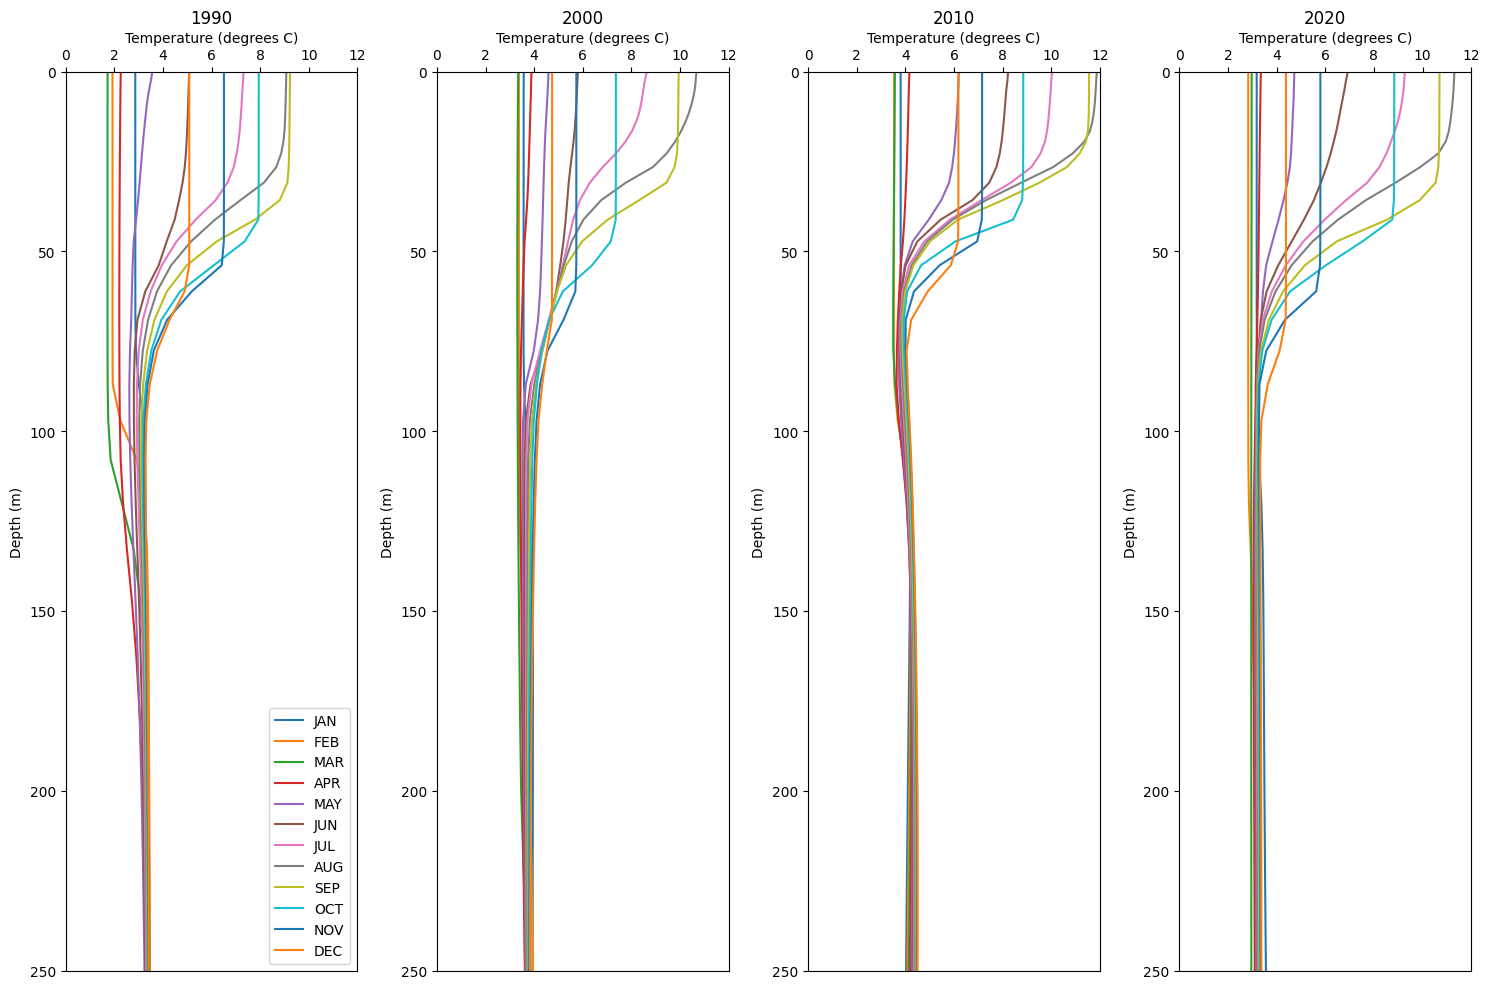

In [61]:
fig, ax = plt.subplots(1, 4, figsize = (15, 10))
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

for i in range(0,12):
    data = temp90.isel(time_counter = i)
    ax[0].plot(data.values, data['deptht'].values, label = months[i])
    ax[0].set_title('1990')
    
for i in range(0,12):
    data = temp00.isel(time_counter = i)
    ax[1].plot(data.values, data['deptht'].values, label = months[i])
    ax[1].set_title('2000')

for i in range(0,12):
    data = temp10.isel(time_counter = i)
    ax[2].plot(data.values, data['deptht'].values, label = months[i])
    ax[2].set_title('2010')

for i in range(0,12):
    data = temp20.isel(time_counter = i)
    ax[3].plot(data.values, data['deptht'].values, label = months[i])
    ax[3].set_title('2020')

for a in ax:
    a.set_xlim(0, 12)
    a.set_ylim(0, 250)
    a.invert_yaxis()
    a.set_xlabel('Temperature (degrees C)')
    a.set_ylabel('Depth (m)')
    a.xaxis.tick_top()                
    a.xaxis.set_label_position('top')

ax[0].legend(loc = 'best')

plt.tight_layout()
plt.show()

In [25]:
## Consider 30 W, 55N 

point = ds.sel(gphit = 55.0, glamt = -30.0, method = 'nearest')
temp90 = point['thetao_con'].where(ds['time_counter'].dt.year == 1990, drop =True).compute()
temp00 = point['thetao_con'].where(ds['time_counter'].dt.year == 2000, drop =True).compute()
temp10 = point['thetao_con'].where(ds['time_counter'].dt.year == 2010, drop =True).compute()
temp20 = point['thetao_con'].where(ds['time_counter'].dt.year == 2020, drop =True).compute()

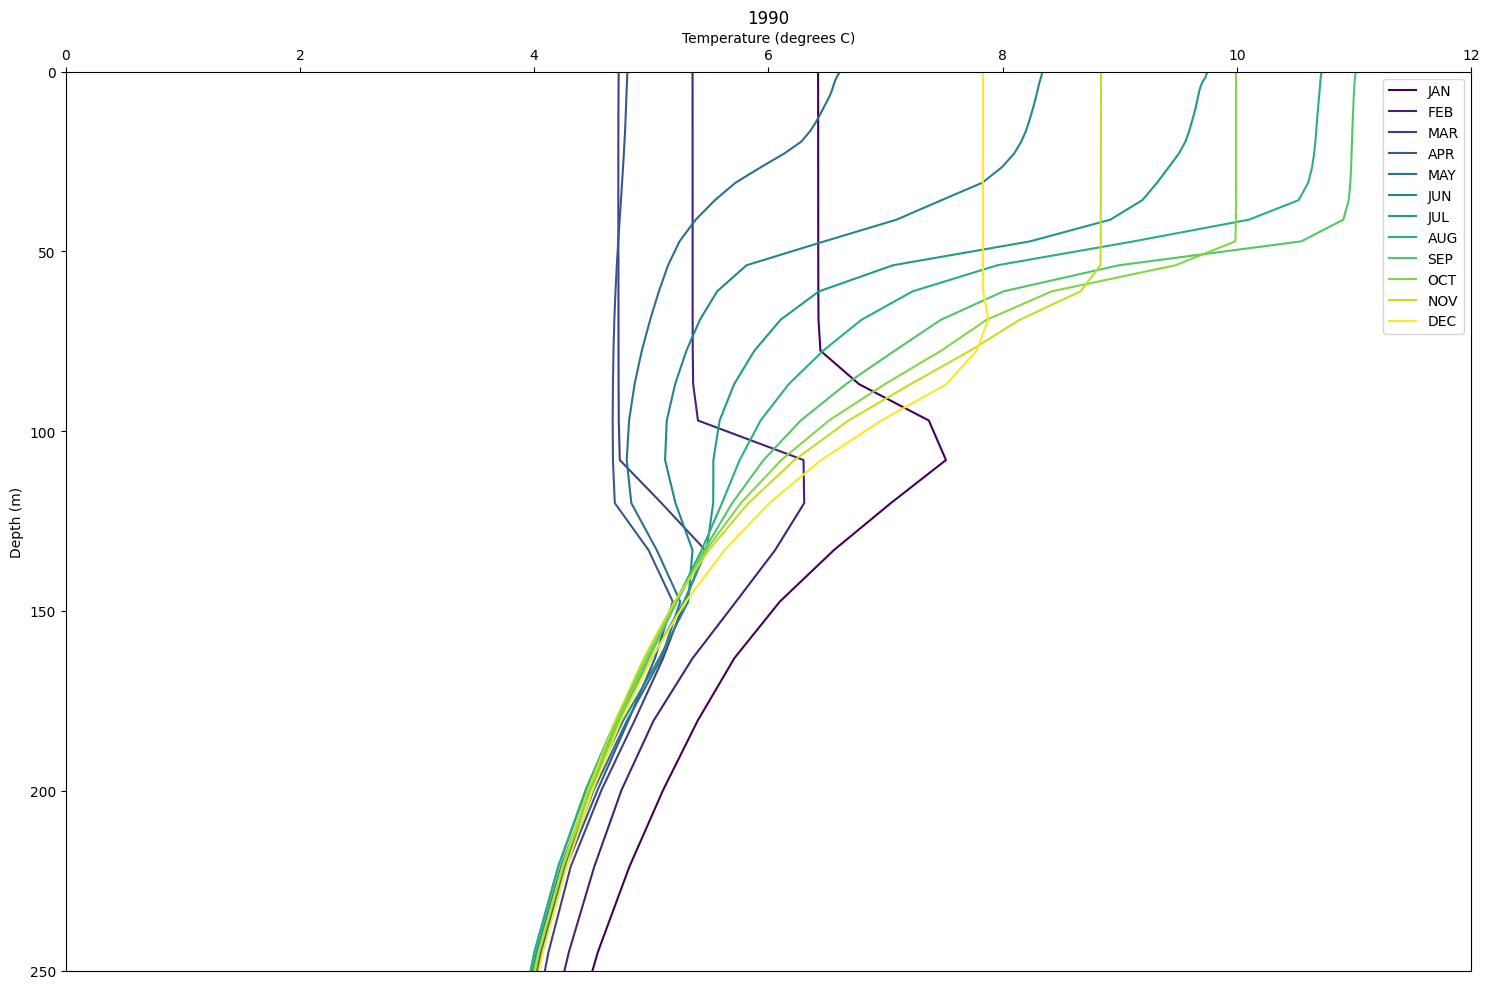

In [32]:
fig, ax = plt.subplots(figsize = (15, 10))
cmap = plt.cm.viridis               
colors = cmap(np.linspace(0, 1, 12))
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

for i in range(0,12):
    data = temp90.isel(time_counter = i)
    ax.plot(data.values, data['deptht'].values, label = months[i], color = colors[i])

ax.set_title('1990')
ax.set_xlim(0, 12)
ax.set_ylim(0, 250)
ax.invert_yaxis()
ax.set_xlabel('Temperature (degrees C)')
ax.set_ylabel('Depth (m)')
ax.xaxis.tick_top()                
ax.xaxis.set_label_position('top')
ax.legend(loc = 'best')
plt.savefig('1990.png')
plt.tight_layout()
plt.show()

In [29]:
temp24 = point['thetao_con'].where(ds['time_counter'].dt.year == 2024, drop =True).compute()


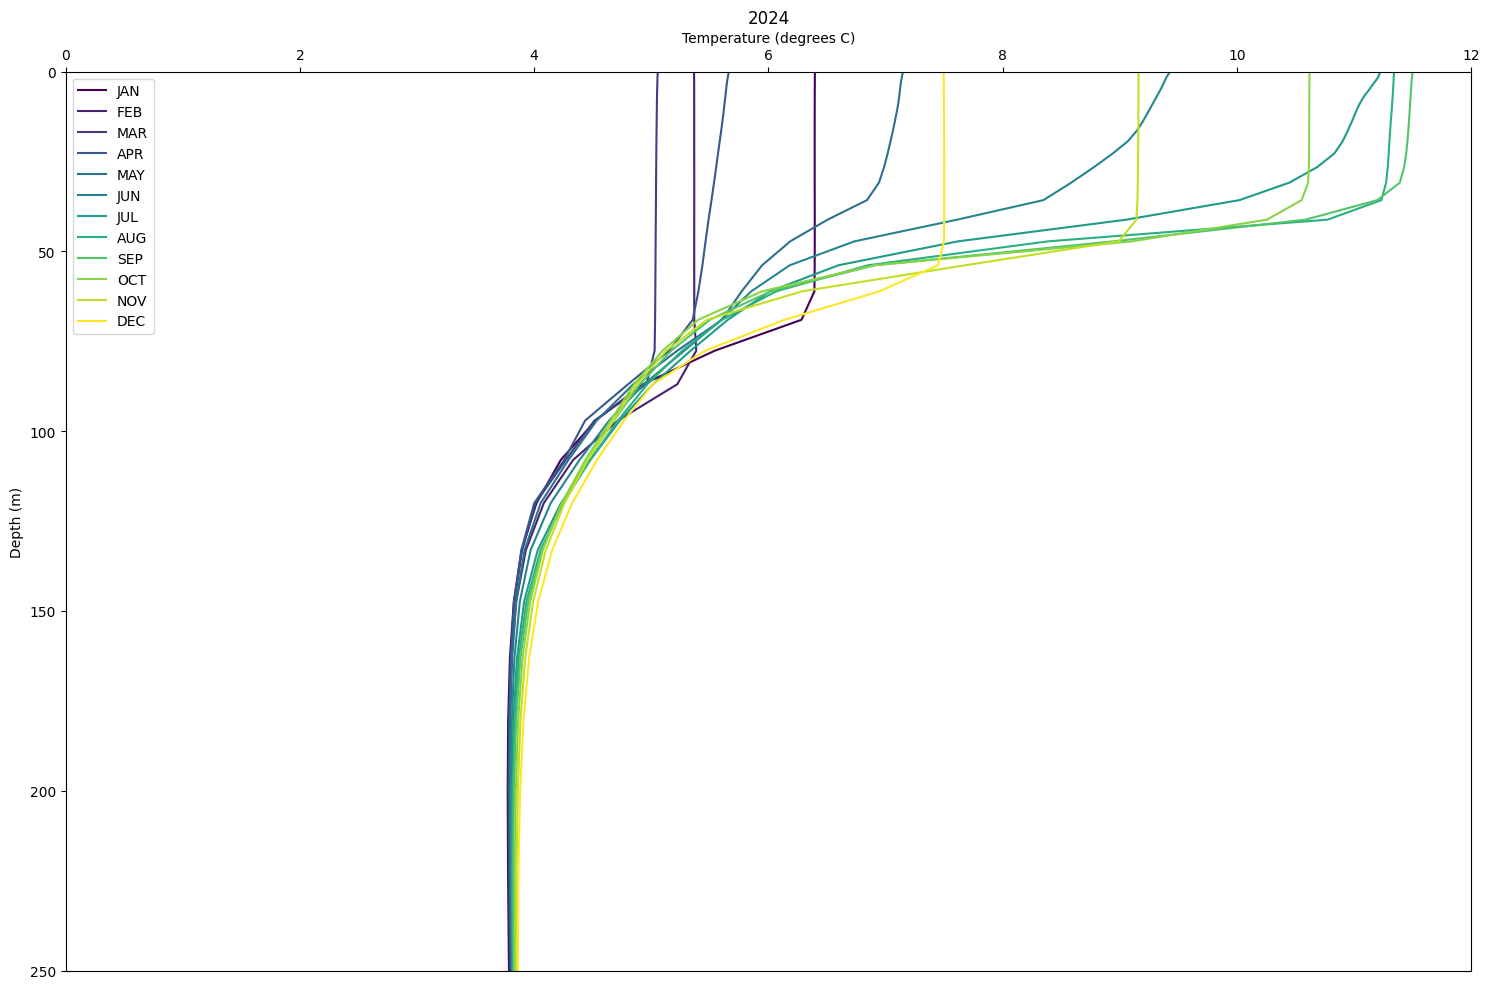

In [33]:
fig, ax = plt.subplots(figsize = (15, 10))
cmap = plt.cm.viridis               
colors = cmap(np.linspace(0, 1, 12))
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

for i in range(0,12):
    data = temp24.isel(time_counter = i)
    ax.plot(data.values, data['deptht'].values, label = months[i], color = colors[i])

ax.set_title('2024')
ax.set_xlim(0, 12)
ax.set_ylim(0, 250)
ax.invert_yaxis()
ax.set_xlabel('Temperature (degrees C)')
ax.set_ylabel('Depth (m)')
ax.xaxis.tick_top()                
ax.xaxis.set_label_position('top')
ax.legend(loc = 'best')
plt.savefig('2024.png')
plt.tight_layout()
plt.show()

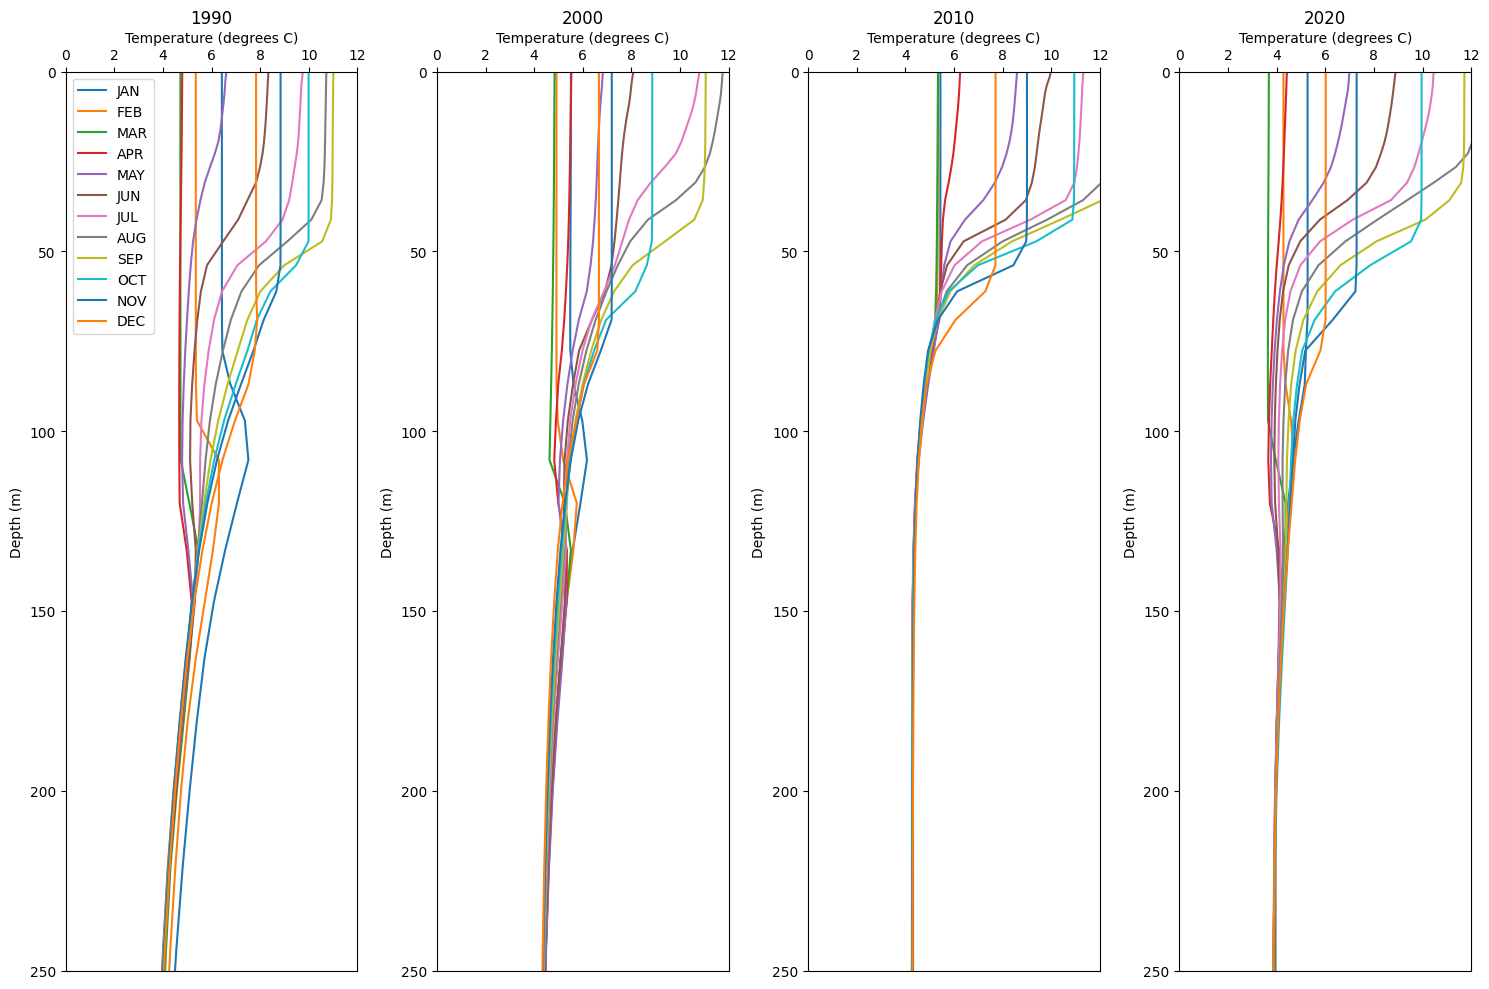

In [64]:
fig, ax = plt.subplots(1, 4, figsize = (15, 10))
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

for i in range(0,12):
    data = temp90.isel(time_counter = i)
    ax[0].plot(data.values, data['deptht'].values, label = months[i])
    ax[0].set_title('1990')
    
for i in range(0,12):
    data = temp00.isel(time_counter = i)
    ax[1].plot(data.values, data['deptht'].values, label = months[i])
    ax[1].set_title('2000')

for i in range(0,12):
    data = temp10.isel(time_counter = i)
    ax[2].plot(data.values, data['deptht'].values, label = months[i])
    ax[2].set_title('2010')

for i in range(0,12):
    data = temp20.isel(time_counter = i)
    ax[3].plot(data.values, data['deptht'].values, label = months[i])
    ax[3].set_title('2020')

for a in ax:
    a.set_xlim(0, 12)
    a.set_ylim(0, 250)
    a.invert_yaxis()
    a.set_xlabel('Temperature (degrees C)')
    a.set_ylabel('Depth (m)')
    a.xaxis.tick_top()                
    a.xaxis.set_label_position('top')

ax[0].legend(loc = 'best')

plt.tight_layout()
plt.show()

In [6]:
## Consider 30W, 55N - February

point = ds.sel(gphit = 55.0, glamt = -30.0, method = 'nearest')
tempFEB = point['thetao_con'].where(ds['time_counter'].dt.month == 2, drop =True).compute()


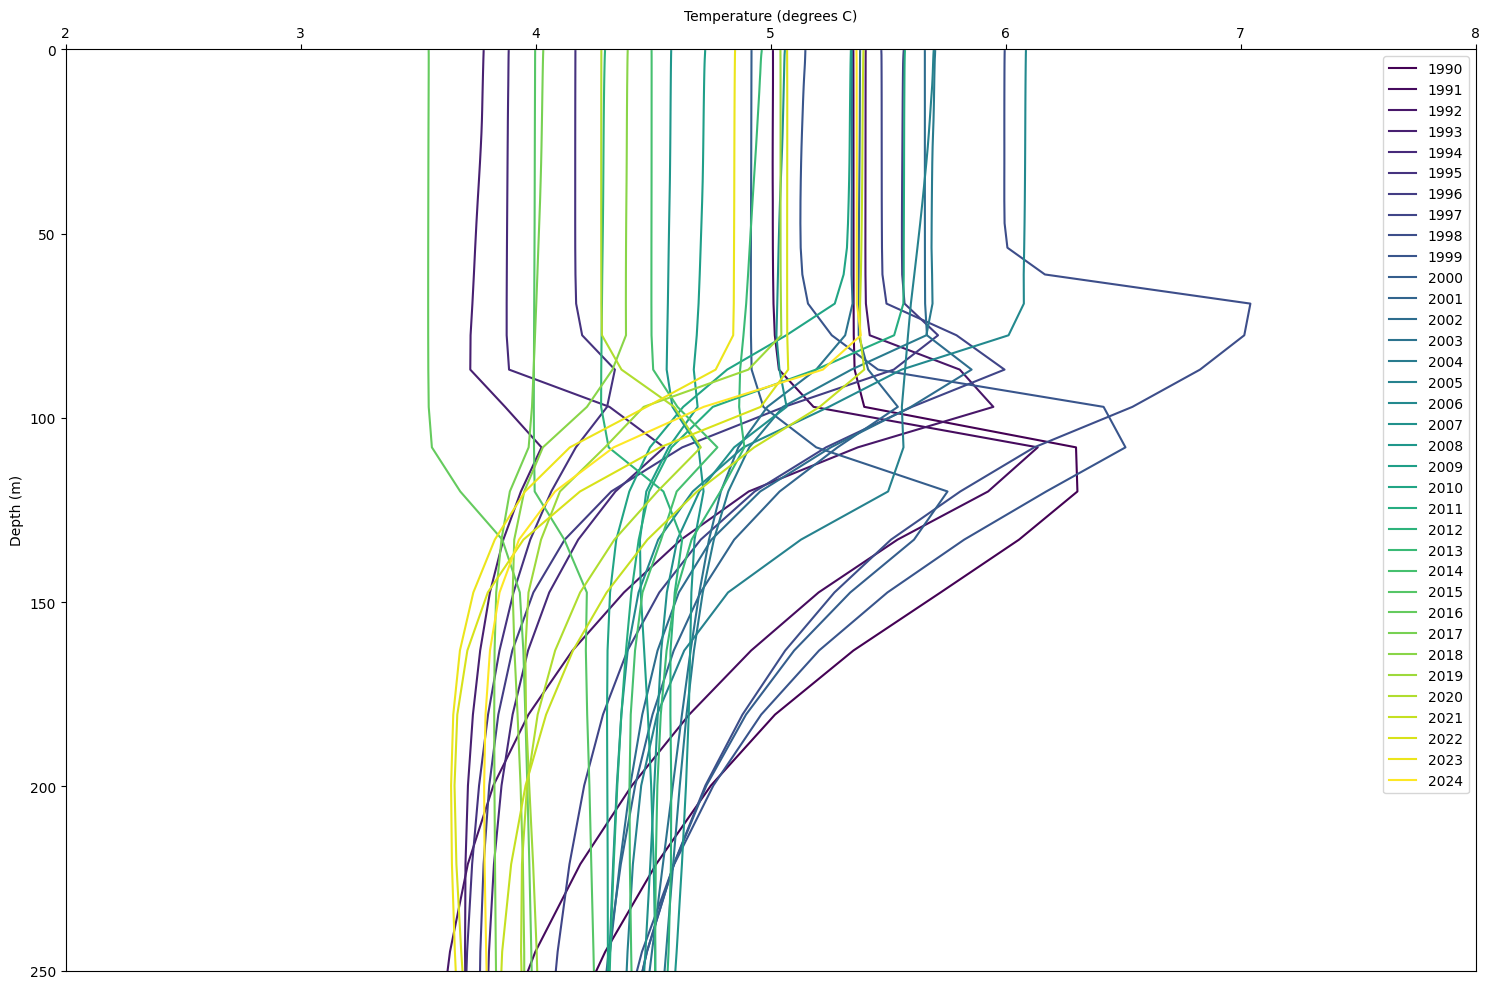

In [38]:
fig, ax = plt.subplots(figsize = (15, 10))
years = np.arange(1990, 2025)

cmap = plt.cm.viridis               
colors = cmap(np.linspace(0, 1, len(years)))


for i in range(0, 35):
    data = tempFEB.isel(time_counter = i)
    ax.plot(data.values, data['deptht'].values, label = years[i], color = colors[i])

ax.set_xlim(2, 8)
ax.set_ylim(0, 250)
ax.invert_yaxis()
ax.set_xlabel('Temperature (degrees C)')
ax.set_ylabel('Depth (m)')
ax.xaxis.tick_top()                
ax.xaxis.set_label_position('top')
ax.legend(loc = 'best')
plt.tight_layout()
plt.savefig('FEB.png')
plt.show()

In [3]:
## Consider 30W, 55N - September

point = ds.sel(gphit = 55.0, glamt = -30.0, method = 'nearest')
tempSEP = point['thetao_con'].where(ds['time_counter'].dt.month == 9, drop =True).compute()


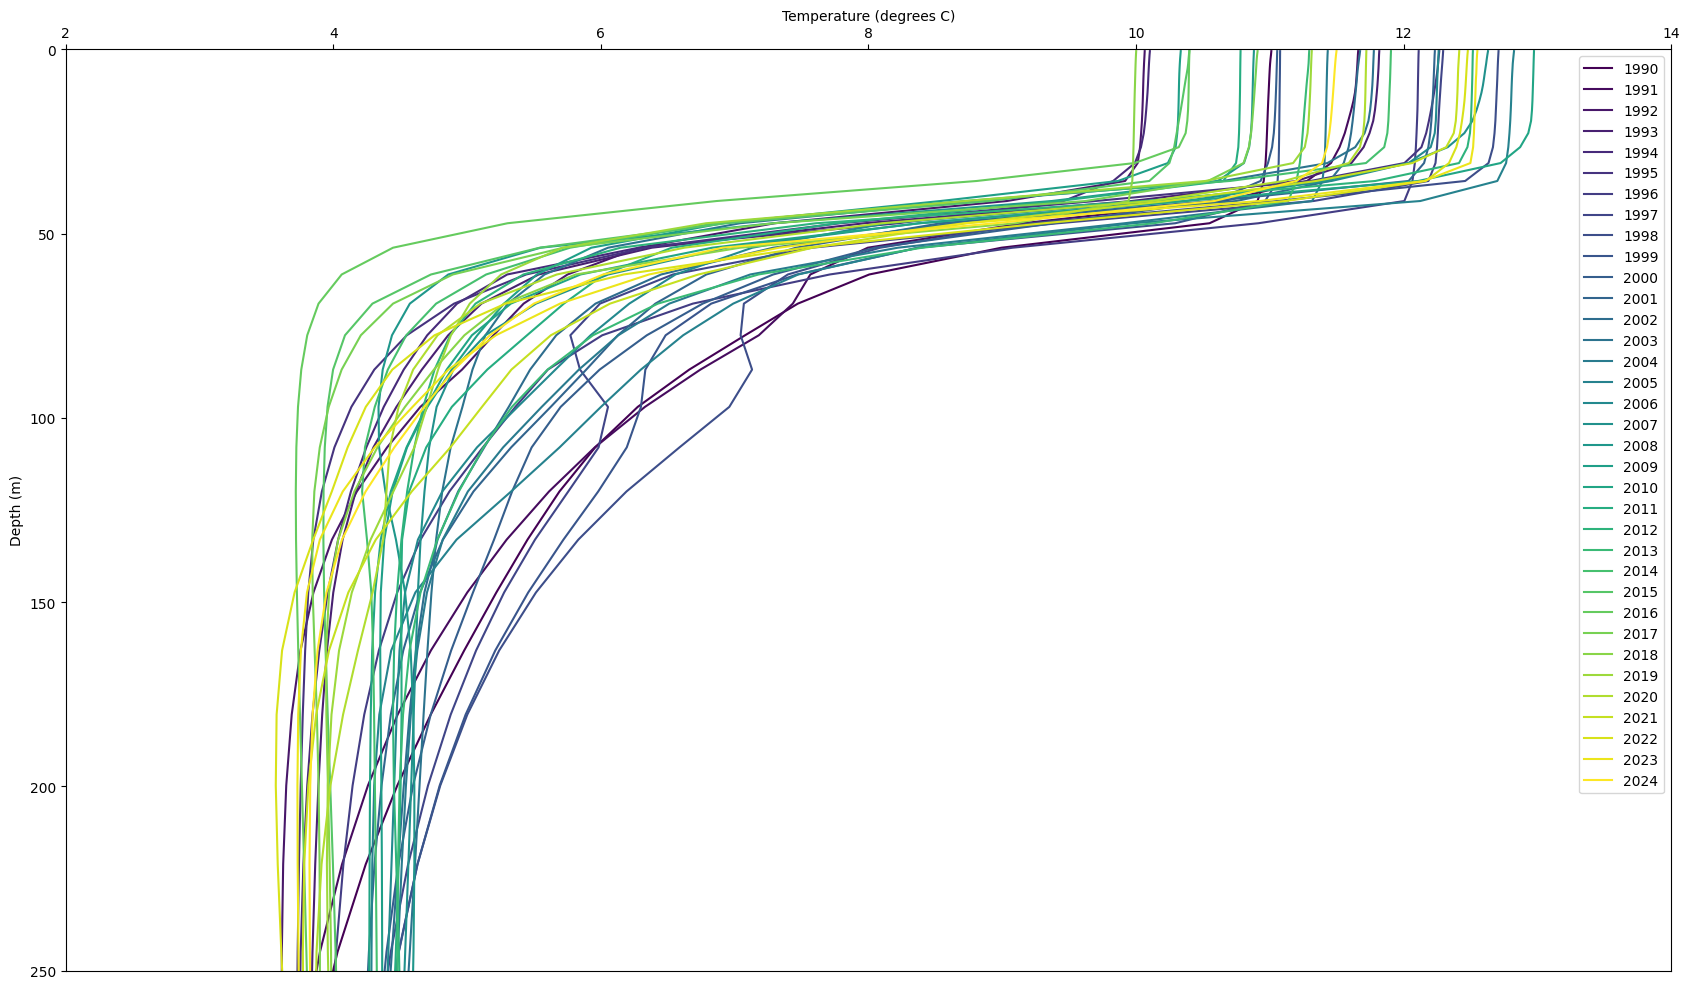

In [5]:
fig, ax = plt.subplots(figsize = (17, 10))
years = np.arange(1990, 2025)

cmap = plt.cm.viridis               
colors = cmap(np.linspace(0, 1, len(years)))


for i in range(0, 35):
    data = tempSEP.isel(time_counter = i)
    ax.plot(data.values, data['deptht'].values, label = years[i], color = colors[i])

ax.set_xlim(2, 14)
ax.set_ylim(0, 250)
ax.invert_yaxis()
ax.set_xlabel('Temperature (degrees C)')
ax.set_ylabel('Depth (m)')
ax.xaxis.tick_top()                
ax.xaxis.set_label_position('top')
ax.legend(loc = 'best')
plt.savefig('SEP.png')
plt.tight_layout()
plt.show()